In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import os
from scipy.stats import pearsonr


#to get font to work
font_dir = os.path.expanduser("/home/mbrannon/.fonts")
font_files = fm.findSystemFonts(fontpaths=[font_dir])
for font_file in font_files:
    fm.fontManager.addfont(font_file)
plt.rcParams["font.family"] = "IBM Plex Sans"
rcParams["font.sans-serif"] = ["IBM Plex Sans"]


In [3]:
#Step 1: find replicates -- AG with same DS number

In [5]:
meta = pd.read_table('/net/seq/data2/projects/sabramov/SuperIndex/dnase-index0415/matrices/downsampled_no_cancer/metadata.tsv')
dsmeta = meta[['ag_id','extended_annotation','ds_number']]

# Group and aggregate
df_grouped = (
    dsmeta.groupby('ds_number')
    .apply(lambda x: pd.Series({
        'ag_list': x['ag_id'].tolist(),
        'extended_annotation': x['extended_annotation'].iloc[0]
    }))
    .reset_index()
)

# Keep only groups with more than one AG
df_grouped = df_grouped[df_grouped['ag_list'].apply(len) > 1]

In [6]:
df_grouped

,ds_number,ag_list,extended_annotation
598,DS25294,"[AG62140, AG62144]",Macrophage
682,DS28804,"[AG62082, AG70890]",Macrophage
768,DS36706,"[AG80153, AG80120]",Hippocampus
772,DS36719,"[AG80155, AG80187]",Basal ganglia
773,DS36720,"[AG80182, AG80100]",Basal ganglia
775,DS36816,"[AG80183, AG80118]",Basal ganglia
777,DS36837,"[AG80188, AG80117]",Basal ganglia
786,DS37124,"[AG3856, AG6254]",Pancreas
789,DS37150,"[AG3857, AG7031]",Pancreas
790,DS37156,"[AG3858, AG6253]",Pancreas


In [34]:
#select cell type of interest
cell_type = 'T-cell'
cell_rows = df_grouped[df_grouped["extended_annotation"].str.contains(cell_type, case=False, na=False)]

In [35]:
cell_rows

,ds_number,ag_list,extended_annotation
3059,DS93650,"[AG72394, AG72387]",T-cell


In [36]:
ag1 = cell_rows['ag_list'].values[0][0]
ag2 = cell_rows['ag_list'].values[0][1]

In [37]:
#run this in terminal
print(f"bedtools intersect \
    -a /home/mbrannon/tmp/ag_preds/{ag1}.predictions.tsv \
    -b /home/mbrannon/tmp/ag_preds/{ag2}.predictions.tsv \
    -wa -wb -f 0.5 > /home/mbrannon/tmp/ag_preds/{ag1}_{ag2}_overlap.tsv")


bedtools intersect     -a /home/mbrannon/tmp/ag_preds/AG72394.predictions.tsv     -b /home/mbrannon/tmp/ag_preds/AG72387.predictions.tsv     -wa -wb -f 0.5 > /home/mbrannon/tmp/ag_preds/AG72394_AG72387_overlap.tsv


In [38]:
overlap_df = pd.read_csv(
    f"/home/mbrannon/tmp/ag_preds/{ag1}_{ag2}_overlap.tsv",
    sep="\t",
    header=None
)
overlap_df.columns = [
    'chrom1','start1','end1','target_counts1','pred_counts1','log_target_counts1','log_pred_counts1',
    'chrom2','start2','end2','target_counts2','pred_counts2','log_target_counts2','log_pred_counts2'
]

#compute correlation
corr, _ = pearsonr(overlap_df['log_target_counts1'], overlap_df['log_target_counts2'])
print(f"Pearson correlation of target_counts between replicates: {corr:.4f}")


Pearson correlation of target_counts between replicates: 0.9760


In [39]:
overlap_df

,chrom1,start1,end1,target_counts1,pred_counts1,log_target_counts1,log_pred_counts1,chrom2,start2,end2,target_counts2,pred_counts2,log_target_counts2,log_pred_counts2
0,chr1,869760,869983,654.999957,234.758010,6.486161,5.462806,chr1,869776,870009,995.999986,328.493013,6.904751,5.797555
1,chr1,904591,904853,607.000022,336.251920,6.410175,5.820830,chr1,904624,904864,1143.999990,497.207828,7.043160,6.211017
2,chr1,921069,921371,71.000000,21.364224,4.276666,3.107463,chr1,921100,921367,115.999999,47.000238,4.762174,3.871206
3,chr1,923760,923983,324.000006,87.150564,5.783825,4.479046,chr1,923750,923979,559.999973,78.104327,6.329721,4.370768
4,chr1,940320,940639,69.000001,37.846742,4.248495,3.659624,chr1,940290,940976,54.000002,36.356291,4.007333,3.620501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55229,chrY,19745080,19745219,48.000002,210.709839,3.891820,5.355217,chrY,19744610,19745188,122.999996,222.071818,4.820282,5.407494
55230,chrY,20575518,20575840,530.000013,469.473630,6.274762,6.153740,chrY,20575505,20575823,824.999989,524.023793,6.716595,6.263444
55231,chrY,20925411,20925635,67.999999,49.574315,4.234106,3.923444,chrY,20925424,20925678,97.000003,87.291178,4.584968,4.480640
55232,chrY,21240230,21240466,42.999998,49.026314,3.784190,3.912549,chrY,21240256,21240510,50.000001,62.132800,3.931826,4.145240


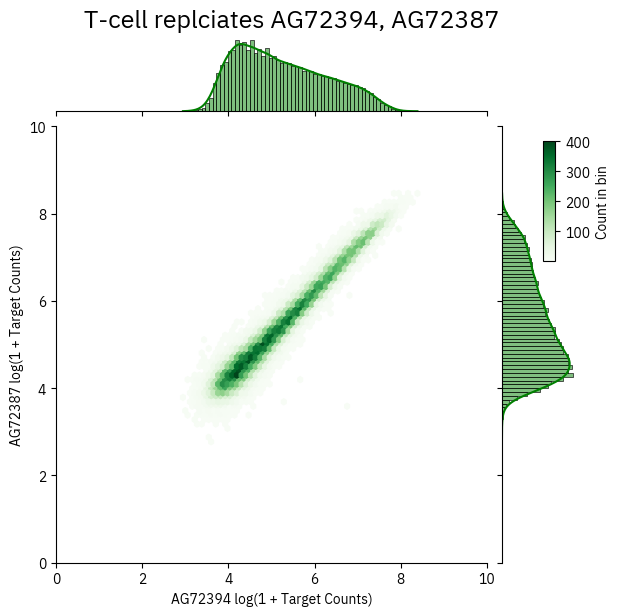

In [41]:
# Apply log transformation (handles 0s safely)

plot = sns.jointplot(
    x="log_target_counts1", 
    y="log_target_counts2", 
    data=overlap_df,
    kind='hex',
    cmap = 'Greens',
    marginal_kws=dict(color = 'Green', kde=True),
    height=6,
    gridsize=50,
    mincnt=1
)

plot.ax_joint.set_xlim(0, 10)   # adjust to your data range
plot.ax_joint.set_ylim(0, 10)


# Add title with Pearson r and p-value
plot.fig.suptitle(f"{cell_type} replciates {ag1}, {ag2}", fontsize=18, y=1.02)

# Axis labels
plot.set_axis_labels(f"{ag1} log(1 + Target Counts)", f"{ag2} log(1 + Target Counts)")

# Custom colorbar position
cbar_ax = plot.fig.add_axes([.92, .6, .02, .2])
plt.colorbar(plot.ax_joint.collections[0], cax=cbar_ax, label="Count in bin")

plt.show()


In [ ]:
#mse
overlap_df["squared_error"] = (overlap_df["log_target_counts1"] - overlap_df["log_target_counts2"])**2

# Mean Squared Error
mse = overlap_df["squared_error"].mean()
print(f"Mean Squared Error: {mse:.2f}")
